# Marginal Velocity Decomposition and Posterior MCMC

The accompanying blog post [Flow Matching as Posterior Averaging](https://nbrosse.github.io/posts/intro-fm-diffusion/intro-fm-diffusion.html) explains the theory and the code in more detail.

In [1]:
import numpy as np

from intro_fm_diffusion.notebook import (
    ExperimentConfig,
    analyze_cfm_decomposition_by_time,
    analyze_training_plateau_vs_global_cfm,
    analyze_velocity_fields_on_grid,
    run_notebook_demo_training,
)
from intro_fm_diffusion.viz import (
    plot_cfm_decomposition_by_time,
    plot_late_training_plateau,
    plot_learned_vs_marginal_velocity_grid,
    plot_posterior_mcmc_grid,
    plot_training_loss_linear_log,
)


## Reproducibility Configuration

All experiment parameters are centralized in a single config object. The model is trained once and reused in all downstream analyses.

In [2]:
CONFIG = ExperimentConfig(
    seed=42,
    device="auto",
    nmodes=5,
    target_std=1.0,
    target_scale=10.0,
    hidden_layers=(64, 64, 64, 64),
    num_epochs=2_000,
    learning_rate=1e-3,
    batch_size=1_000,
)

print(CONFIG)

ExperimentConfig(seed=42, device='auto', nmodes=5, target_std=1.0, target_scale=10.0, hidden_layers=(64, 64, 64, 64), num_epochs=2000, learning_rate=0.001, batch_size=1000)


## Train Once

Run one training pass and reuse the resulting `path`, `model`, and `losses` everywhere else in this notebook.

In [3]:
run = run_notebook_demo_training(CONFIG)

path = run.path
model = run.model
losses = run.losses

print(f"Final training loss: {losses[-1]:.4f}")
print(f"Mean of last 100 losses: {float(np.mean(losses[-100:])):.4f}")


Epoch 1999, loss: 12.382390975952148: 100%|██████████| 2000/2000 [00:04<00:00, 453.70it/s]

Final training loss: 12.3824
Mean of last 100 losses: 12.4747


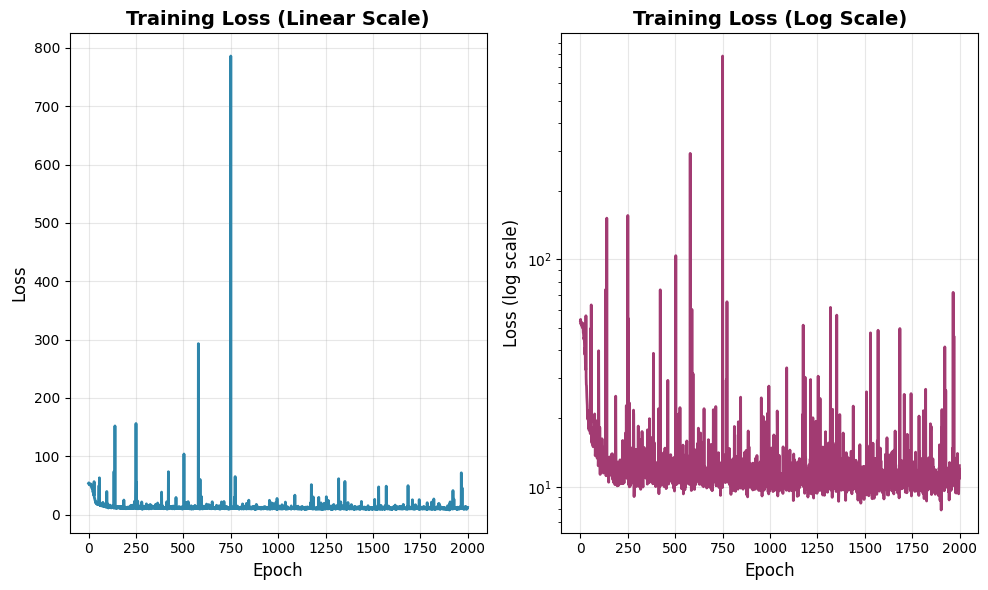

In [4]:
fig, axes = plot_training_loss_linear_log(losses);
fig.savefig("../figures/training_loss.png", dpi=200, bbox_inches="tight")


## Velocity Field Analysis

For this Gaussian-mixture setup, exact posterior formulas are available.

100%|██████████| 6/6 [00:00<00:00, 623.18it/s]


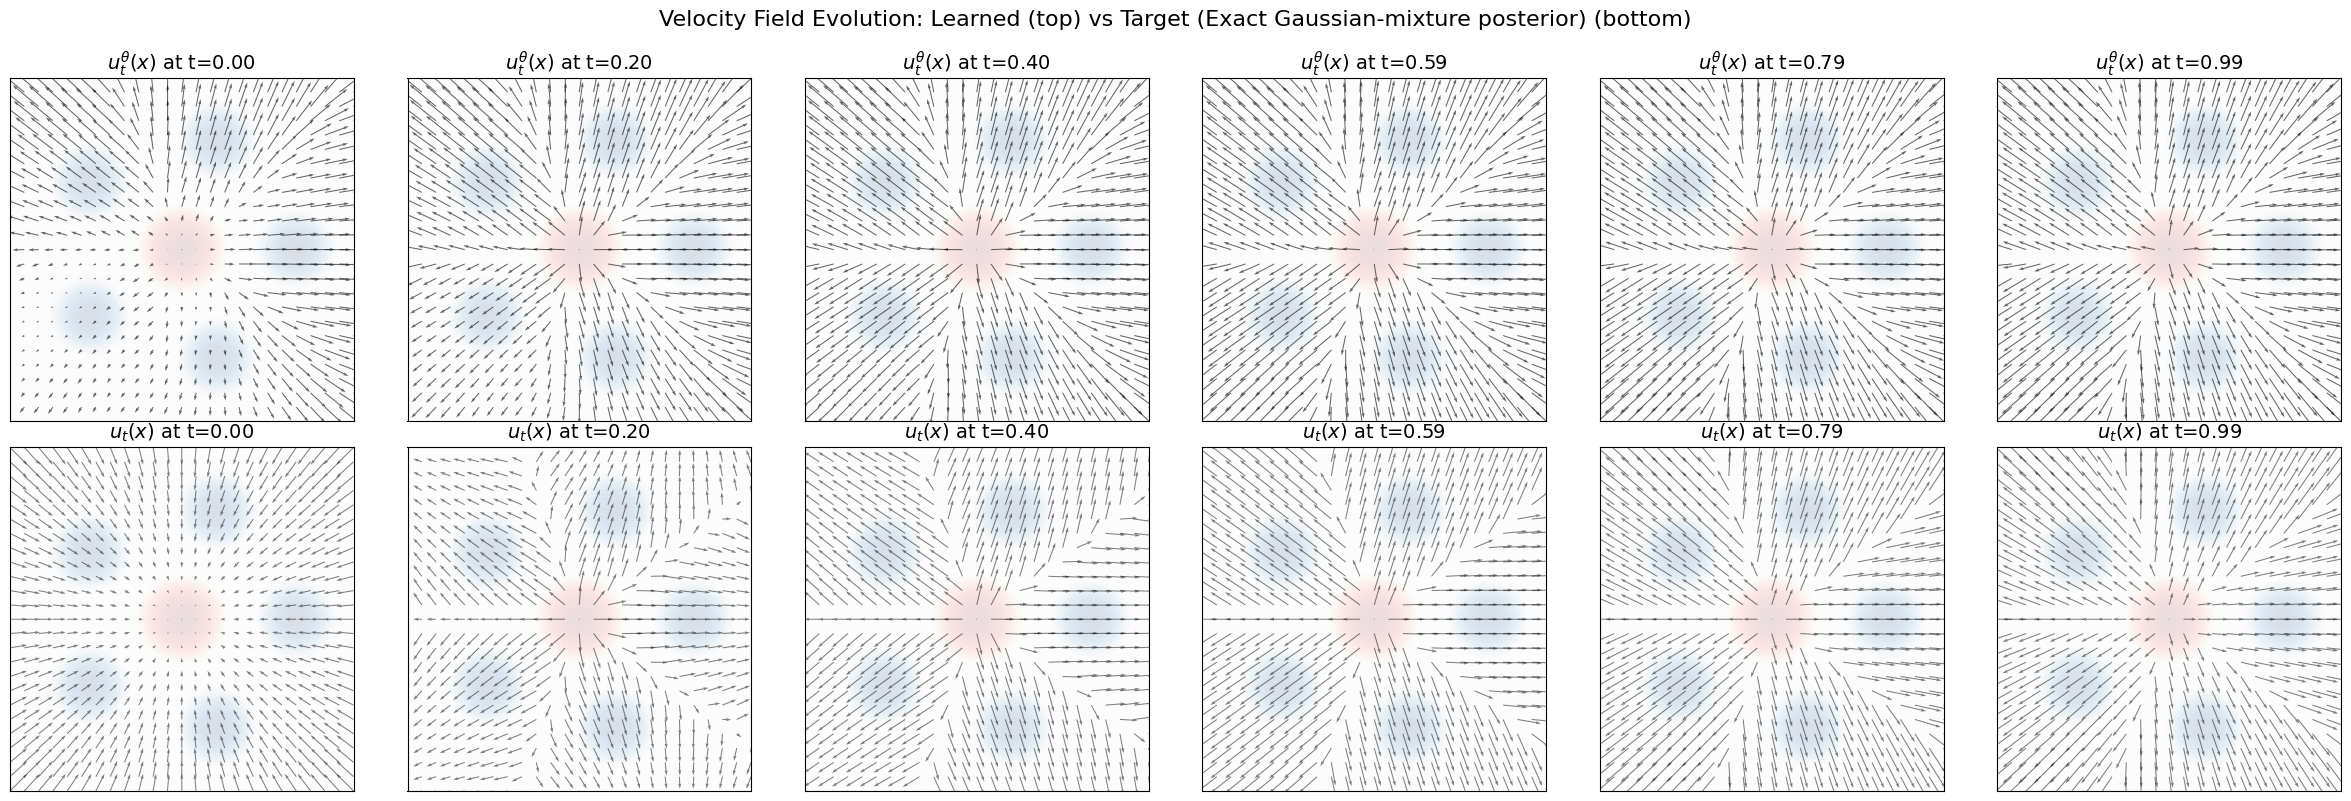

In [5]:
exact = analyze_velocity_fields_on_grid(
    path=path,
    velocity_model=model,
    scale=15.0,
    num_bins=25,
    num_time_steps=6,
    num_posterior_samples=500,
    posterior_method="exact",
)

fig, axes = plot_learned_vs_marginal_velocity_grid(exact, path, scale=15.0);
fig.savefig("../figures/velocity_fields.png", dpi=200, bbox_inches="tight")


## Loss Decomposition (FM, CFM, Irreducible Variance)

The FM and irreducible-variance terms use posterior information. CFM is sampled directly from the conditional path.

Computing irreducible variance (exact): 100%|██████████| 20/20 [00:00<00:00, 1552.99it/s]


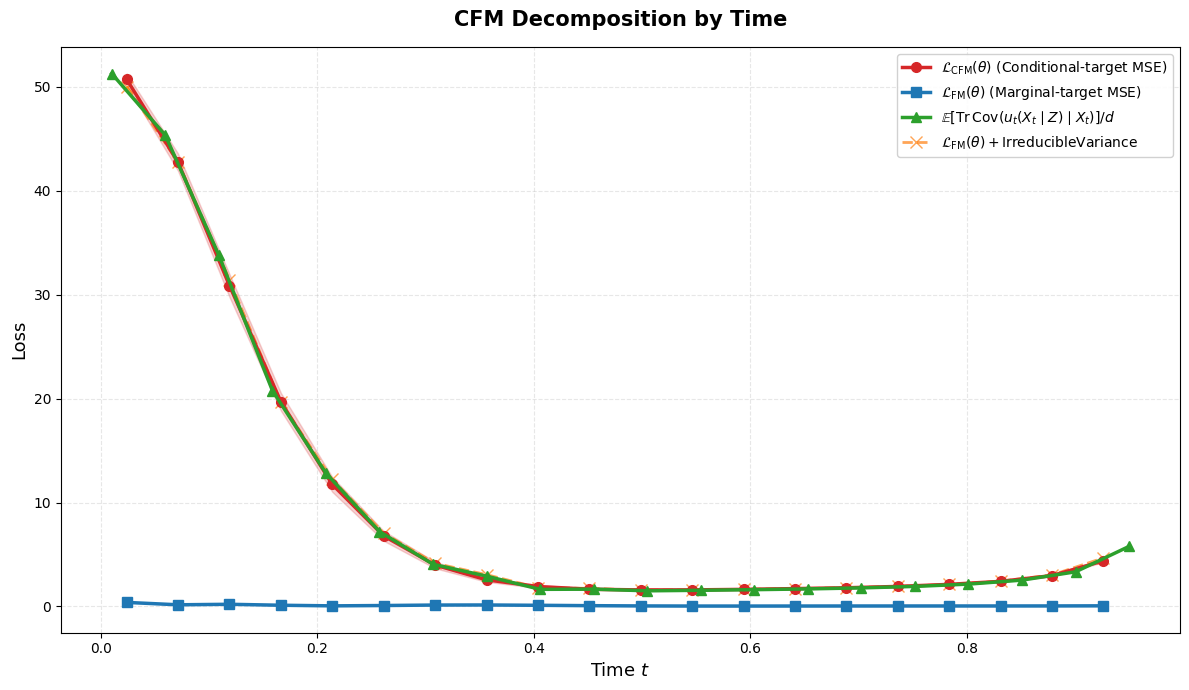

Marginal mean loss: 0.0996
Conditional mean loss: 9.7441
Mean irreducible variance: 10.2712


In [6]:
decomposition = analyze_cfm_decomposition_by_time(
    path=path,
    velocity_model=model,
    batch_size=1_000,
    num_batches=100,
    num_posterior_samples=500,
    num_time_bins=20,
    t_min=0.0,
    t_max=0.95,
    variance_num_samples=100,
    variance_num_time_steps=20,
    posterior_method="exact",
)

fig, axes = plot_cfm_decomposition_by_time(
    decomposition["marginal_by_time"],
    decomposition["conditional_by_time"],
    decomposition["irreducible_variance_by_time"],
);
fig.savefig("../figures/loss_decomposition.png", dpi=200, bbox_inches="tight")

print(f"Marginal mean loss: {float(np.mean(decomposition['marginal_by_time']['mean_losses'])):.4f}")
print(f"Conditional mean loss: {float(np.mean(decomposition['conditional_by_time']['mean_losses'])):.4f}")
print(f"Mean irreducible variance: {decomposition['irreducible_variance_by_time']['mean_variance']:.4f}")


## Training Loss Plateau

Compare the late-stage training loss with a global empirical CFM estimate.

Computing global conditional-target MSE: 100%|██████████| 200/200 [00:00<00:00, 1310.88it/s]


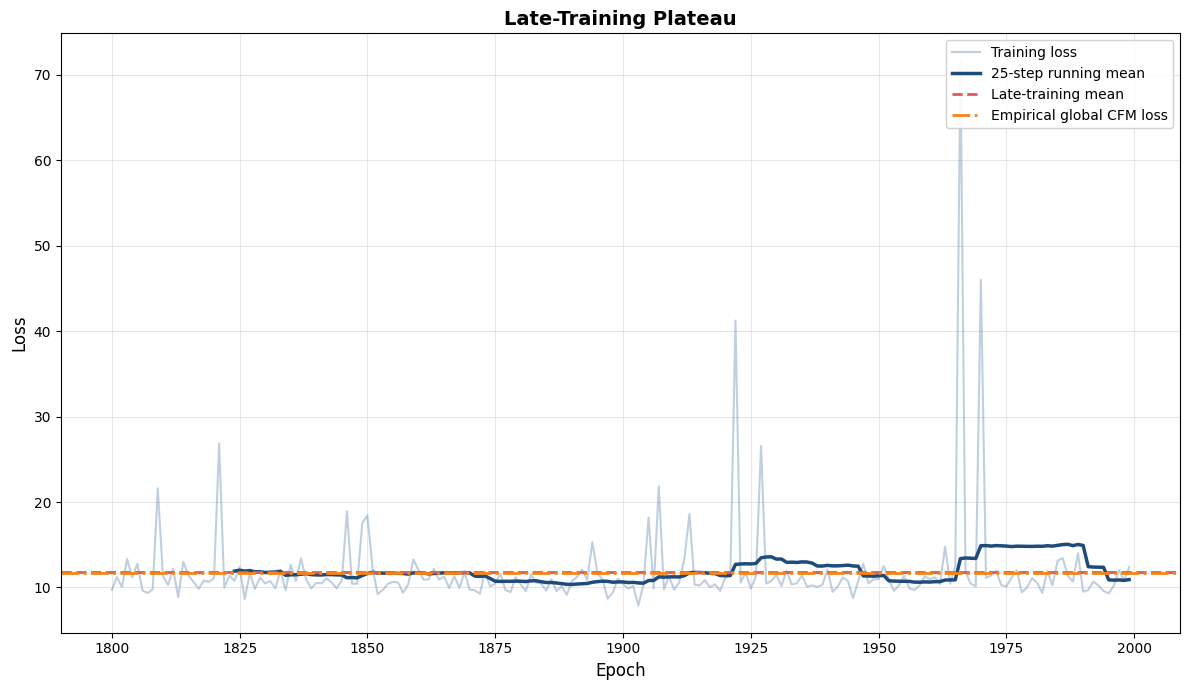

In [9]:
plateau_analysis = analyze_training_plateau_vs_global_cfm(
    path=path,
    velocity_model=model,
    training_losses=losses,
    plateau_window=200,
    global_batch_size=1_000,
    global_num_batches=200,
    global_t_min=0.0,
    global_t_max=1.0,
)

fig, axes = plot_late_training_plateau(losses, plateau_analysis);
fig.savefig("../figures/training_loss_plateau.png", dpi=200, bbox_inches="tight")



## Posterior MCMC Visualization

Visualize posterior trajectories.

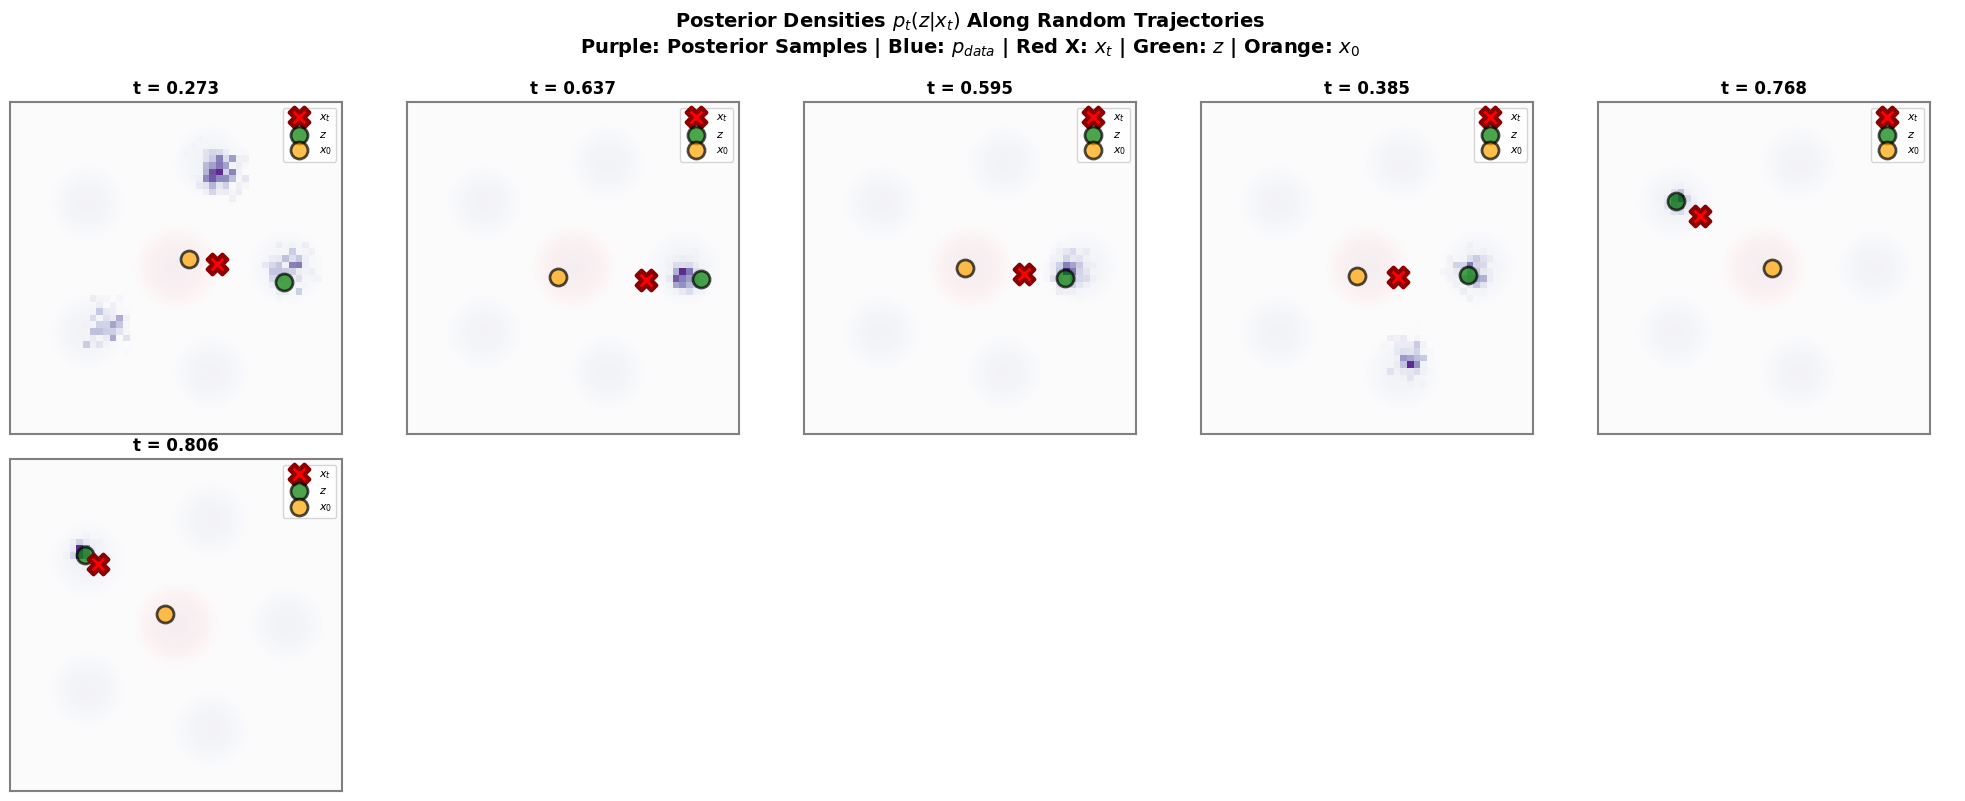

In [8]:
mcmc_method = "metropolis"
num_burnin = 500
num_chains = 4
num_posterior_samples = 250

fig, axes = plot_posterior_mcmc_grid(
    path,
    scale=15.0,
    num_trajectories=6,
    num_posterior_samples=num_posterior_samples,
    method=mcmc_method,
    num_burnin=num_burnin,
    num_chains=num_chains,
    seed=CONFIG.seed,
);

fig.savefig("../figures/posterior_mcmc.png", dpi=200, bbox_inches="tight")